<a href="https://colab.research.google.com/github/yansudarshan/nlp_/blob/main/ml_challenge_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# import training data

In [2]:
import pandas as pd
import numpy as np

file_path = '/content/drive/MyDrive/train.csv'
train_df = pd.read_csv(file_path)

print(f"Successfully loaded {file_path}")
print(train_df.head())

Successfully loaded /content/drive/MyDrive/train.csv
   sample_id                                    catalog_content  \
0      33127  Item Name: La Victoria Green Taco Sauce Mild, ...   
1     198967  Item Name: Salerno Cookies, The Original Butte...   
2     261251  Item Name: Bear Creek Hearty Soup Bowl, Creamy...   
3      55858  Item Name: Judee’s Blue Cheese Powder 11.25 oz...   
4     292686  Item Name: kedem Sherry Cooking Wine, 12.7 Oun...   

                                          image_link  price  
0  https://m.media-amazon.com/images/I/51mo8htwTH...   4.89  
1  https://m.media-amazon.com/images/I/71YtriIHAA...  13.12  
2  https://m.media-amazon.com/images/I/51+PFEe-w-...   1.97  
3  https://m.media-amazon.com/images/I/41mu0HAToD...  30.34  
4  https://m.media-amazon.com/images/I/41sA037+Qv...  66.49  


In [3]:
train_df.head()

,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49


In [4]:
train_df = train_df.drop(columns=['catalog_content'])

In [5]:
train_df.head()

,sample_id,image_link,price
0,33127,https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97
3,55858,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34
4,292686,https://m.media-amazon.com/images/I/41sA037+Qv...,66.49


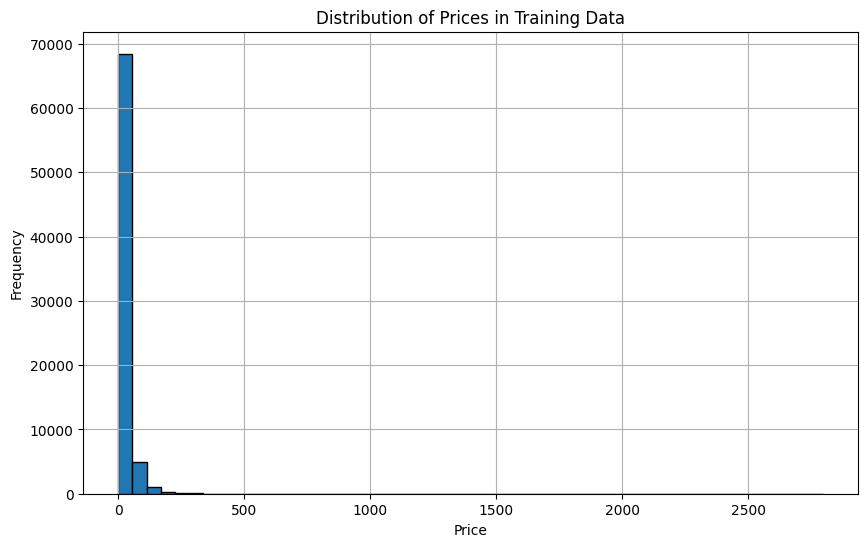

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(train_df['price'], bins=50, edgecolor='black')
plt.title('Distribution of Prices in Training Data')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# import test data

In [7]:
file_path = '/content/drive/MyDrive/test.csv'
test_df = pd.read_csv(file_path)

print(f"Successfully loaded {file_path}")
print(test_df.head())

Successfully loaded /content/drive/MyDrive/test.csv
   sample_id                                    catalog_content  \
0     100179  Item Name: Rani 14-Spice Eshamaya's Mango Chut...   
1     245611  Item Name: Natural MILK TEA Flavoring extract ...   
2     146263  Item Name: Honey Filled Hard Candy - Bulk Pack...   
3      95658  Item Name: Vlasic Snack'mm's Kosher Dill 16 Oz...   
4      36806  Item Name: McCormick Culinary Vanilla Extract,...   

                                          image_link  
0  https://m.media-amazon.com/images/I/71hoAn78AW...  
1  https://m.media-amazon.com/images/I/61ex8NHCIj...  
2  https://m.media-amazon.com/images/I/61KCM61J8e...  
3  https://m.media-amazon.com/images/I/51Ex6uOH7y...  
4  https://m.media-amazon.com/images/I/71QYlrOMoS...  


In [8]:
test_df.head()

,sample_id,catalog_content,image_link
0,100179,Item Name: Rani 14-Spice Eshamaya's Mango Chut...,https://m.media-amazon.com/images/I/71hoAn78AW...
1,245611,Item Name: Natural MILK TEA Flavoring extract ...,https://m.media-amazon.com/images/I/61ex8NHCIj...
2,146263,Item Name: Honey Filled Hard Candy - Bulk Pack...,https://m.media-amazon.com/images/I/61KCM61J8e...
3,95658,Item Name: Vlasic Snack'mm's Kosher Dill 16 Oz...,https://m.media-amazon.com/images/I/51Ex6uOH7y...
4,36806,"Item Name: McCormick Culinary Vanilla Extract,...",https://m.media-amazon.com/images/I/71QYlrOMoS...


In [9]:
test_df = test_df.drop(columns=['catalog_content'])
test_df.head()

,sample_id,image_link
0,100179,https://m.media-amazon.com/images/I/71hoAn78AW...
1,245611,https://m.media-amazon.com/images/I/61ex8NHCIj...
2,146263,https://m.media-amazon.com/images/I/61KCM61J8e...
3,95658,https://m.media-amazon.com/images/I/51Ex6uOH7y...
4,36806,https://m.media-amazon.com/images/I/71QYlrOMoS...


## Generate Image Embeddings using Vision Transformer (ViT)

This section will:
1.  Install necessary libraries (`transformers`, `torch`, `Pillow`, `requests`).
2.  Load a pre-trained Vision Transformer model and its image processor.
3.  Define a function to download images, preprocess them, and generate embeddings in batches.
4.  Apply this function to the `image_link` column of `train_df`.
5.  Create a new DataFrame `train_embedding_df` containing `sample_id`, the generated `embedding` vectors, and `price`.

In [10]:
# Install necessary libraries
!pip install transformers torch requests Pillow tqdm

In [11]:
import torch
import requests
from PIL import Image
import io
from transformers import AutoImageProcessor, AutoModel
from tqdm.notebook import tqdm
import numpy as np

# Set up device (GPU if available, else CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load pre-trained ViT model and processor
model_name = "google/vit-base-patch16-224-in21k" # A common and robust ViT model
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

# Determine the embedding dimension for placeholder if image download fails
dummy_image = Image.new('RGB', (processor.size['height'], processor.size['width']))
dummy_inputs = processor(images=dummy_image, return_tensors="pt").to(device)
with torch.no_grad():
    dummy_outputs = model(**dummy_inputs)
    # Using the [CLS] token embedding for ViT
    EMBEDDING_DIM = dummy_outputs.last_hidden_state[:, 0, :].shape[-1]
print(f"Determined embedding dimension: {EMBEDDING_DIM}")

Using device: cuda


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Determined embedding dimension: 768


In [12]:
def get_image_embeddings_batch(image_urls, processor, model, device, embedding_dim):
    embeddings_list = []
    for url in image_urls:
        try:
            response = requests.get(url, stream=True, timeout=10) # Added timeout
            response.raise_for_status()  # Raise an exception for HTTP errors (4xx or 5xx)
            image = Image.open(io.BytesIO(response.content)).convert("RGB")

            inputs = processor(images=image, return_tensors="pt").to(device)
            with torch.no_grad():
                outputs = model(**inputs)

            # Extract the [CLS] token embedding and convert to numpy array
            image_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy().flatten()
            embeddings_list.append(image_embedding)

        except requests.exceptions.RequestException as e:
            print(f"Warning: Could not download image from {url}. Error: {e}")
            embeddings_list.append(np.zeros(embedding_dim)) # Append a zero vector as placeholder
        except Image.UnidentifiedImageError:
            print(f"Warning: Could not identify image from {url}. It might be corrupted or in an unsupported format.")
            embeddings_list.append(np.zeros(embedding_dim))
        except Exception as e:
            print(f"Warning: An unexpected error occurred for image from {url}. Error: {e}")
            embeddings_list.append(np.zeros(embedding_dim)) # Generic error handling

    return embeddings_list

In [13]:
# Generate embeddings for train_df in batches
batch_size = 32 # Adjust based on your GPU memory and preference
all_embeddings = []

print(f"Starting embedding generation for {len(train_df)} images with batch size {batch_size}...")
for i in tqdm(range(0, len(train_df), batch_size), desc="Generating Embeddings"):
    batch_urls = train_df['image_link'].iloc[i:i+batch_size].tolist()
    batch_embeddings = get_image_embeddings_batch(batch_urls, processor, model, device, EMBEDDING_DIM)
    all_embeddings.extend(batch_embeddings)

print("Embedding generation complete.")

Starting embedding generation for 75000 images with batch size 32...


Generating Embeddings:   0%|          | 0/2344 [00:00<?, ?it/s]

Embedding generation complete.


In [14]:
# Create the new DataFrame train_embedding_df
train_embedding_df = pd.DataFrame({
    'embedding': all_embeddings,
    'price': train_df['price']
})

print("train_embedding_df created successfully with 'sample_id', 'embedding', and 'price' columns:")
display(train_embedding_df.head())

train_embedding_df created successfully with 'sample_id', 'embedding', and 'price' columns:


,embedding,price
0,"[-0.09603889, 0.122991845, -0.13443393, 0.0997...",4.89
1,"[0.09730833, -0.0075851735, 0.08583509, 0.1373...",13.12
2,"[0.039495748, -0.0059906906, 0.090012334, -0.0...",1.97
3,"[-0.08363343, -0.3662983, 0.18312621, 0.093286...",30.34
4,"[-0.009834491, -0.1316043, 0.40902182, 0.01155...",66.49


In [17]:
train_embedding_df['price'] = np.log1p(train_embedding_df['price'])

print("Price column in train_embedding_df converted to log(price):")
display(train_embedding_df.head())

Price column in train_embedding_df converted to log(price):


/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,embedding,price
0,"[-0.09603889, 0.122991845, -0.13443393, 0.0997...",0.379783
1,"[0.09730833, -0.0075851735, 0.08583509, 0.1373...",0.665527
2,"[0.039495748, -0.0059906906, 0.090012334, -0.0...",-0.491936
3,"[-0.08363343, -0.3662983, 0.18312621, 0.093286...",0.800851
4,"[-0.009834491, -0.1316043, 0.40902182, 0.01155...",0.889693


### Correcting NaN values in the target variable

The `np.log1p` transformation can result in `NaN` values if the original price was zero or negative (though prices are typically positive, very small positive values might become problematic if not handled by `log1p` correctly). We must remove these rows before training the model.

In [29]:
# Identify and drop rows with NaN values in the 'price' column after log transformation
initial_rows = len(train_embedding_df)
train_embedding_df.dropna(subset=['price'], inplace=True)
final_rows = len(train_embedding_df)

print(f"Removed {initial_rows - final_rows} rows containing NaN values in 'price' after log transformation.")
print(f"train_embedding_df now has {final_rows} rows.")

display(train_embedding_df.head())

Removed 982 rows containing NaN values in 'price' after log transformation.
train_embedding_df now has 74018 rows.


,embedding,price
0,"[-0.09603889, 0.122991845, -0.13443393, 0.0997...",0.379783
1,"[0.09730833, -0.0075851735, 0.08583509, 0.1373...",0.665527
2,"[0.039495748, -0.0059906906, 0.090012334, -0.0...",-0.491936
3,"[-0.08363343, -0.3662983, 0.18312621, 0.093286...",0.800851
4,"[-0.009834491, -0.1316043, 0.40902182, 0.01155...",0.889693


### Re-prepare Data for LightGBM

Now that NaN values are handled, we need to re-create our feature (X) and target (y) arrays from the cleaned `train_embedding_df`.

In [30]:
# Convert list of embeddings to a 2D NumPy array
X = np.array(train_embedding_df['embedding'].tolist())
y = train_embedding_df['price']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (74018, 768)
Shape of target (y): (74018,)


### Re-split Data into Training and Validation Sets

We need to re-split the data using the cleaned X and y.

# Now train a model LightGBM

In [31]:
# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

X_train shape: (59214, 768)
X_val shape: (14804, 768)
y_train shape: (59214,)
y_val shape: (14804,)


### Re-train LightGBM Model

Now with clean data, we can re-train the `LGBMRegressor` model.

In [32]:
# Initialize and train the LGBM Regressor model
model = LGBMRegressor(random_state=42)
model.fit(X_train, y_train)

print("LightGBM model trained successfully with clean data.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.810063 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 59214, number of used features: 768
[LightGBM] [Info] Start training from score 0.589668
LightGBM model trained successfully with clean data.


### Evaluate Model Performance with SMAPE

Let's evaluate the trained model on the validation set using Mean Squared Error (MSE), R-squared, and the Symmetric Mean Absolute Percentage Error (SMAPE) metric. Remember to inverse transform the predictions and actuals for SMAPE calculation as the model predicts log-transformed prices.

In [33]:
# Make predictions on the validation set
y_pred_log = model.predict(X_val)

# Inverse transform log-predictions and actuals for SMAPE
y_pred_original = np.expm1(y_pred_log) # Using expm1 because we used log1p
y_val_original = np.expm1(y_val)

# Ensure no negative or zero values after inverse transform for SMAPE denominator
y_pred_original[y_pred_original < 0] = 0.001 # Small positive value
y_val_original[y_val_original < 0] = 0.001 # Small positive value

# Evaluate the model using original log-transformed values for MSE and R2 (as per common practice for log-transformed targets)
mse = mean_squared_error(y_val, y_pred_log)
r2 = r2_score(y_val, y_pred_log)

# Calculate SMAPE
def smape(y_true, y_pred):
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    # Handle cases where denominator might be zero to avoid division by zero
    # A small epsilon or conditional logic can be used here.
    # For this implementation, we assume denominator won't be zero given small positive values for original prices
    return np.mean(numerator / denominator) * 100 # Multiply by 100 for percentage

smape_score = smape(y_val_original, y_pred_original)

print(f"Mean Squared Error (MSE) on validation set (log-transformed): {mse:.4f}")
print(f"R-squared (R2) on validation set (log-transformed): {r2:.4f}")
print(f"Symmetric Mean Absolute Percentage Error (SMAPE) on validation set: {smape_score:.2f}%")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Mean Squared Error (MSE) on validation set (log-transformed): 0.1207
R-squared (R2) on validation set (log-transformed): 0.1627
Symmetric Mean Absolute Percentage Error (SMAPE) on validation set: 43.89%


### Visualize Prediction Errors

To understand where the model is struggling, let's visualize the distribution of the prediction errors (residuals) and a scatter plot of actual vs. predicted prices.

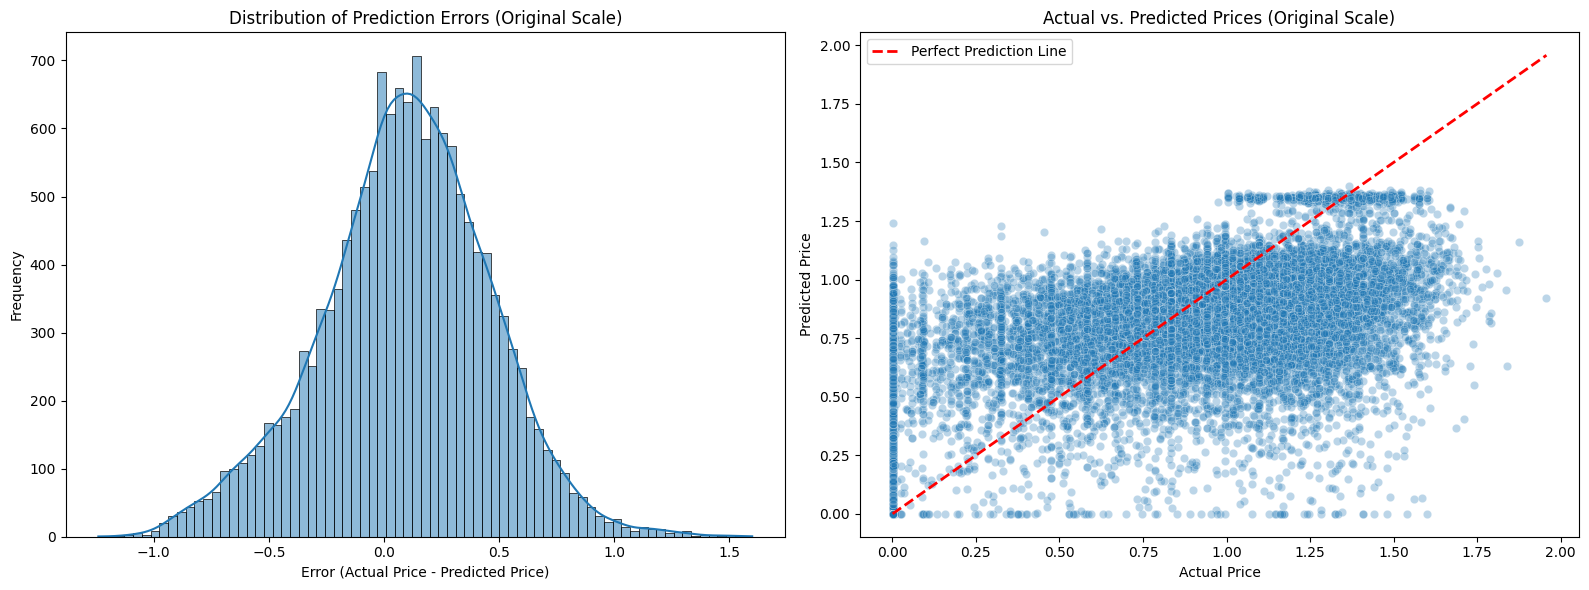

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals (errors) on the original scale for better interpretability
residuals_original = y_val_original - y_pred_original

# Plotting the distribution of residuals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(residuals_original, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Prediction Errors (Original Scale)')
axes[0].set_xlabel('Error (Actual Price - Predicted Price)')
axes[0].set_ylabel('Frequency')

# Plotting actual vs. predicted values
sns.scatterplot(x=y_val_original, y=y_pred_original, ax=axes[1], alpha=0.3)
axes[1].plot([min(y_val_original), max(y_val_original)], [min(y_val_original), max(y_val_original)],
             color='red', linestyle='--', lw=2, label='Perfect Prediction Line')
axes[1].set_title('Actual vs. Predicted Prices (Original Scale)')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].legend()

plt.tight_layout()
plt.show()

### Handle NaN values in the target variable

The `np.log1p` transformation can introduce `NaN` values if the original price is very small or negative. We need to remove these rows to ensure our model can be trained successfully.

In [34]:
# Identify and drop rows with NaN values in the 'price' column
initial_rows = len(train_embedding_df)
train_embedding_df.dropna(subset=['price'], inplace=True)
final_rows = len(train_embedding_df)

print(f"Removed {initial_rows - final_rows} rows containing NaN values in 'price'.")
print(f"train_embedding_df now has {final_rows} rows.")

display(train_embedding_df.head())

Removed 0 rows containing NaN values in 'price'.
train_embedding_df now has 74018 rows.


,embedding,price
0,"[-0.09603889, 0.122991845, -0.13443393, 0.0997...",0.379783
1,"[0.09730833, -0.0075851735, 0.08583509, 0.1373...",0.665527
2,"[0.039495748, -0.0059906906, 0.090012334, -0.0...",-0.491936
3,"[-0.08363343, -0.3662983, 0.18312621, 0.093286...",0.800851
4,"[-0.009834491, -0.1316043, 0.40902182, 0.01155...",0.889693


### Handle NaN values in the target variable

The `np.log1p` transformation can introduce `NaN` values if the original price is very small or negative. We need to remove these rows to ensure our model can be trained successfully.

In [35]:
# Identify and drop rows with NaN values in the 'price' column
initial_rows = len(train_embedding_df)
train_embedding_df.dropna(subset=['price'], inplace=True)
final_rows = len(train_embedding_df)

print(f"Removed {initial_rows - final_rows} rows containing NaN values in 'price'.")
print(f"train_embedding_df now has {final_rows} rows.")

display(train_embedding_df.head())

Removed 0 rows containing NaN values in 'price'.
train_embedding_df now has 74018 rows.


,embedding,price
0,"[-0.09603889, 0.122991845, -0.13443393, 0.0997...",0.379783
1,"[0.09730833, -0.0075851735, 0.08583509, 0.1373...",0.665527
2,"[0.039495748, -0.0059906906, 0.090012334, -0.0...",-0.491936
3,"[-0.08363343, -0.3662983, 0.18312621, 0.093286...",0.800851
4,"[-0.009834491, -0.1316043, 0.40902182, 0.01155...",0.889693


### Hyperparameter Tuning for LightGBM

To potentially improve the model's performance, let's perform hyperparameter tuning using `RandomizedSearchCV`. This will search for the best combination of parameters from a defined distribution.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 500, 1000],
    'learning_rate': uniform(0.01, 0.19), # From 0.01 to 0.2
    'num_leaves': [20, 31, 40, 50, 60],
    'max_depth': [-1, 5, 8, 12, 15],
    'min_child_samples': [20, 30, 50, 100],
    'subsample': uniform(0.6, 0.4), # From 0.6 to 1.0
    'colsample_bytree': uniform(0.6, 0.4) # From 0.6 to 1.0
}

# Initialize LGBMRegressor
lgbm = LGBMRegressor(random_state=42)

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled. Reduce if it takes too long.
# cv: Number of cross-validation folds.
random_search = RandomizedSearchCV(lgbm,
                                   param_distributions=param_dist,
                                   n_iter=50,
                                   cv=3,
                                   scoring='neg_mean_squared_error',
                                   verbose=1,
                                   n_jobs=-1, # Use all available cores
                                   random_state=42)

# Fit RandomizedSearchCV to the training data
print("Starting RandomizedSearchCV for hyperparameter tuning...")
random_search.fit(X_train, y_train)
print("RandomizedSearchCV completed.")

# Print the best parameters and best score
print(f"Best parameters found: {random_search.best_params_}")
print(f"Best negative MSE (which is -MSE): {random_search.best_score_:.4f}")

Starting RandomizedSearchCV for hyperparameter tuning...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


### Train New Model with Best Hyperparameters

Now we'll use the best parameters found by `RandomizedSearchCV` to train our final `LGBMRegressor` model.

In [ ]:
# Get the best model from the random search
best_lgbm_model = random_search.best_estimator_

print("Tuned LightGBM model trained successfully.")

### Evaluate Tuned Model Performance

Let's evaluate the performance of the tuned model on the validation set using MSE, R-squared, and SMAPE.

In [ ]:
# Make predictions on the validation set using the tuned model
y_pred_log_tuned = best_lgbm_model.predict(X_val)

# Inverse transform log-predictions and actuals for SMAPE
y_pred_original_tuned = np.expm1(y_pred_log_tuned)
y_val_original_tuned = np.expm1(y_val)

# Ensure no negative or zero values after inverse transform for SMAPE denominator
y_pred_original_tuned[y_pred_original_tuned < 0] = 0.001
y_val_original_tuned[y_val_original_tuned < 0] = 0.001

# Evaluate the tuned model using original log-transformed values for MSE and R2
mse_tuned = mean_squared_error(y_val, y_pred_log_tuned)
r2_tuned = r2_score(y_val, y_pred_log_tuned)

# Calculate SMAPE for the tuned model
smape_score_tuned = smape(y_val_original_tuned, y_pred_original_tuned)

print(f"Tuned Model - Mean Squared Error (MSE) on validation set (log-transformed): {mse_tuned:.4f}")
print(f"Tuned Model - R-squared (R2) on validation set (log-transformed): {r2_tuned:.4f}")
print(f"Tuned Model - Symmetric Mean Absolute Percentage Error (SMAPE) on validation set: {smape_score_tuned:.2f}%")